# Representational Geometry as a Fidelity Metric for Connectome-Constrained Neural Emulations

**Experiment 1: ON Edges | Michael Zhou | Georgia Tech ECE**

This notebook tests whether connectome-constrained networks produce geometrically distinct
population codes compared to randomly initialized networks with the same architecture —
using representational similarity analysis (RSA) applied to the Flyvis Drosophila visual
system model (Lappalainen et al. 2024, *Nature*).

Stimuli: 12 ON moving edges at 30° increments.

**Key question:** Does biological wiring produce a representational geometry that random wiring cannot replicate? If yes, representational geometry is a candidate fidelity metric for connectome-scale neural emulations.

**References**
- Lappalainen et al. 2024. Connectome-constrained networks predict neural activity across the fly visual system. *Nature* 634, 1132–1140. https://www.nature.com/articles/s41586-024-07939-3
- Shiu et al. 2024. A Drosophila computational brain model reveals sensorimotor processing. *Nature* 634, 210–219. https://www.nature.com/articles/s41586-024-07763-9
- Kriegeskorte et al. 2008. Representational similarity analysis. *Frontiers in Systems
  Neuroscience* 2:4. https://www.frontiersin.org/journals/systems-neuroscience/articles/10.3389/neuro.06.004.2008/full
- Kriegeskorte & Wei 2021. Neural tuning and representational geometry. *Nature Reviews
  Neuroscience* 22, 703–718. https://www.nature.com/articles/s41583-021-00502-3
- Nili et al. 2014. A toolbox for representational similarity analysis. *PLOS Computational Biology* 10(4): e1003553. https://doi.org/10.1371/journal.pcbi.1003553
- Brunton et al. 2026. The digital sphinx: Can a worm brain control a fly body? *bioRxiv*.
  https://www.biorxiv.org/content/10.64898/2026.03.20.713233v1

## Setup

Install Flyvis and download pretrained models. Select **Runtime → Change runtime type → GPU**
before running. Tested on T4 GPU (14.56 GiB).

In [1]:
# Install packages
!git clone https://github.com/TuragaLab/flyvis.git
%cd /content/flyvis
!pip install -e .[examples]
!flyvis download-pretrained

Cloning into 'flyvis'...
remote: Enumerating objects: 5230, done.
remote: Counting objects: 100% (247/247), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 5230 (delta 181), reused 155 (delta 122), pack-reused 4983 (from 3)
Receiving objects: 100% (5230/5230), 188.39 MiB | 17.70 MiB/s, done.
Resolving deltas: 100% (2675/2675), done.
/content/flyvis
Obtaining file:///content/flyvis
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.9 MB/s et

## Experiment
**Stimuli:** 12 ON moving edges at 30° increments (0° through 330°)

**Networks:**
- *Connectome-constrained (CC):* All 50 models in the pretrained Flyvis ensemble (indices `000–049` within `flow/0000`, pre-sorted by task error in directory naming), trained to perform optic flow estimation on naturalistic video with connectome-fixed architecture (734 free parameters)
- *Random baseline:* Same 50 model architectures with sign-preserving weight shuffles. Three strategies were tested: (1) full Shiu-style shuffling of all 734 free parameters; (2) matched-normal resampling of all free parameters; and (3) shuffling of only the 604 unitary synapse scaling factors (`edges_syn_strength`) while preserving trained time constants and resting potentials — per Lappalainen et al. (2024) Methods, time constants are clamped during training to prevent instability. Strategy (3) is the canonical baseline for n=50 runs; strategy (1) was used for the exploratory n=10 run that produced a renderable random cosine RDM.

**Population vectors:** Peak central-cell voltage per cell type (65-dim) in response to each stimulus direction

**Reproducibility:** seed=42 (`numpy`, `torch`, `torch.cuda`); `torch.use_deterministic_algorithms(True)`

**Metrics:**
- Cosine distance RDM — scale-invariant, captures pattern geometry
- Euclidean distance RDM — captures magnitude differences
- Spearman RDM correlation — measures similarity between CC and random geometry
- Kendall's $\tau_A$ RDM correlation — preferred for RDM data with ties (Nili et al. 2014); reported alongside Spearman for all CC vs random comparisons
- Within-ensemble consistency — measures stability of CC representational geometry across trained solutions

In [3]:
"""
Experiment 1: Representational Geometry as a Fidelity Metric
for Connectome-Constrained Neural Emulations — ON Edges

This script tests whether connectome-constrained networks (Lappalainen et al. 2024)
produce geometrically distinct population codes compared to randomly initialized
networks with the same architecture.

Experiment:
- Stimuli: 12 moving edge directions (0° through 330°, 30° increments), ON edges
- Networks: pretrained connectome-constrained ensemble (all 50) vs random baseline
- Population vectors: peak central-cell response per cell type (65-dim)
- Metrics: Euclidean distance, cosine distance, RSA (RDM correlation)

Canonical runs:
    # Primary fidelity result (n=10, full Shiu-style shuffle)
    results = run_experiment(n_models=10, randomization_strategy="full_shiu")

    # Instability documentation (n=50, synapse-only shuffle)
    results = run_experiment(n_models=50, randomization_strategy="synapse_only")

Run on Google Colab with GPU runtime after installing flyvis:
    !git clone https://github.com/TuragaLab/flyvis.git
    %cd /content/flyvis
    !pip install -e .[examples]
    !flyvis download-pretrained
"""

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine, euclidean
from scipy.stats import spearmanr, kendalltau
from google.colab import files

# ── 1. IMPORTS ────────────────────────────────────────────────────────────────

import flyvis
from flyvis import results_dir, EnsembleView
from flyvis.network import NetworkView
from flyvis.datasets.moving_bar import MovingEdge
from flyvis.utils.activity_utils import LayerActivity

# ── REPRODUCIBILITY ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True)

# ── 2. STIMULUS DATASET ───────────────────────────────────────────────────────

ANGLES = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]  # 12 directions (30° increments)
INTENSITY = 1                                                        # ON edges only

dataset = MovingEdge(
    offsets=[-10, 11],
    intensities=[0, 1],              # keep both; we'll filter to intensity=1
    speeds=[19],
    height=80,
    post_pad_mode="continue",
    t_pre=1.0,
    t_post=1.0,
    dt=1 / 200,
    angles=ANGLES,
)

print(f"Dataset: {len(dataset)} samples")
print(dataset.arg_df)


# ── 3. HELPER: EXTRACT POPULATION VECTOR ─────────────────────────────────────

def get_population_vector(network_view, stimulus, dt, use_fade_in=True):
    """
    Simulate network response to a single stimulus and return
    peak central-cell voltage per cell type as a population vector.

    Args:
        network_view: flyvis NetworkView instance
        stimulus: tensor of shape (n_frames, 1, 721)
        dt: temporal resolution
        use_fade_in: whether to use fade_in_state initialization

    Returns:
        pop_vec: numpy array of shape (n_cell_types,)
        cell_types: list of cell type names
    """
    network = network_view.init_network()

    # Ensure shape is (n_frames, 1, 721) — MovingEdge returns (n_frames, 721)
    if stimulus.dim() == 2:
        stimulus = stimulus.unsqueeze(1)  # (n_frames, 721) -> (n_frames, 1, 721)

    if use_fade_in:
        initial_state = network.fade_in_state(1.0, dt, stimulus[[0]])
    else:
        initial_state = None

    with torch.no_grad():
        responses = network.simulate(
            stimulus[None], dt, initial_state=initial_state
        ).cpu()

    layer_act = LayerActivity(responses, network.connectome, keepref=True)

    # Use connectome to enumerate cell types — more reliable than central.keys()
    cell_types = [
        ct.decode() if isinstance(ct, bytes) else ct
        for ct in network.connectome.unique_cell_types[:]
    ]
    pop_vec = np.array([
        layer_act.central[ct].squeeze().numpy().max()
        for ct in cell_types
    ])

    # Free GPU memory after each model to avoid OOM on T4 (14.56 GiB)
    del network, responses, layer_act
    torch.cuda.empty_cache()

    return pop_vec, cell_types


# ── 4. HELPER: BUILD RDM ──────────────────────────────────────────────────────

def build_rdm(pop_matrix, metric="cosine"):
    """
    Build a representational dissimilarity matrix from a population matrix.

    Args:
        pop_matrix: numpy array of shape (n_stimuli, n_cells)
        metric: "cosine" or "euclidean"

    Returns:
        rdm: numpy array of shape (n_stimuli, n_stimuli)
    """
    # Replace any inf/nan with large finite value before computing distances.
    # Random baseline networks with unstable dynamics may produce exploding
    # activations; clamping preserves the comparison (an exploding network is
    # maximally different from a well-behaved biological one) while avoiding
    # downstream crashes.
    pop_matrix = np.nan_to_num(pop_matrix, nan=0.0, posinf=1e3, neginf=-1e3)

    n = pop_matrix.shape[0]
    rdm = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                if metric == "cosine":
                    rdm[i, j] = cosine(pop_matrix[i], pop_matrix[j])
                else:
                    rdm[i, j] = euclidean(pop_matrix[i], pop_matrix[j])
    return rdm


# ── 5. HELPER: COMPARE RDMs ──────────────────────────────────────────────────

def rdm_similarity(rdm1, rdm2):
    """
    Compute Spearman rank correlation and Kendall's tau_A between upper
    triangles of two RDMs. Kendall's tau_A is preferred for RDM data with
    ties (Nili et al. 2014); Spearman retained for comparison.
    """
    n = rdm1.shape[0]
    idx = np.triu_indices(n, k=1)
    r_s, p_s = spearmanr(rdm1[idx], rdm2[idx])
    r_k, p_k = kendalltau(rdm1[idx], rdm2[idx])
    return r_s, p_s, r_k, p_k


# ── 5b. HELPER: PERMUTATION TEST ─────────────────────────────────────────────

def permutation_test_rdm(rdm1, rdm2, n_permutations=10000, seed=42):
    """
    Stimulus-label randomization test for RDM correlation (Nili et al. 2014).

    Permutes rows and columns of rdm2 simultaneously to preserve RDM symmetry,
    building a null distribution of RDM correlations under the hypothesis that
    the two RDMs are unrelated. The one-sided p-value is the proportion of
    permuted correlations >= the observed correlation.

    This is the recommended fixed-effects inference procedure from Nili et al.
    (2014) when a single RDM estimate is available (rather than multiple subjects).

    Args:
        rdm1: numpy array of shape (n_stimuli, n_stimuli) — reference RDM
        rdm2: numpy array of shape (n_stimuli, n_stimuli) — candidate RDM
              (stimulus labels of this RDM are permuted)
        n_permutations: number of permutations (default: 10000)
        seed: random seed for reproducibility

    Returns:
        obs_r:    observed Spearman correlation
        p_r:      permutation p-value for Spearman
        obs_tau:  observed Kendall tau_A
        p_tau:    permutation p-value for Kendall tau_A
        null_r:   null distribution of Spearman correlations
        null_tau: null distribution of Kendall tau_A values
    """
    rng = np.random.default_rng(seed)
    n = rdm1.shape[0]
    idx = np.triu_indices(n, k=1)

    # Observed correlations
    obs_r,   _ = spearmanr(rdm1[idx], rdm2[idx])
    obs_tau, _ = kendalltau(rdm1[idx], rdm2[idx])

    # Null distribution via stimulus-label permutation
    null_r   = np.zeros(n_permutations)
    null_tau = np.zeros(n_permutations)

    for i in range(n_permutations):
        perm = rng.permutation(n)
        rdm2_perm = rdm2[np.ix_(perm, perm)]
        null_r[i],   _ = spearmanr(rdm1[idx], rdm2_perm[idx])
        null_tau[i], _ = kendalltau(rdm1[idx], rdm2_perm[idx])

    # One-sided p-value: proportion of null >= observed
    p_r   = np.mean(null_r   >= obs_r)
    p_tau = np.mean(null_tau >= obs_tau)

    return obs_r, p_r, obs_tau, p_tau, null_r, null_tau


# ── 6. HELPER: RANDOM BASELINE NETWORK ───────────────────────────────────────

def randomize_weights(network, strategy="full_shiu"):
    """
    Randomize network weights using the specified strategy, preserving E/I
    sign structure throughout.

    Args:
        network: Flyvis network instance
        strategy: "full_shiu"    — shuffle all 734 free parameters (resting
                                   potentials, time constants, synapse scaling
                                   factors). Used for n=10 primary fidelity runs.
                                   Produces r = 0.757, τ = 0.562 (p < 0.0001).
                  "synapse_only" — shuffle only the 604 unitary synapse scaling
                                   factors (edges_syn_strength), preserving
                                   trained time constants and resting potentials.
                                   Per Lappalainen et al. (2024) Methods, time
                                   constants are clamped during training to prevent
                                   instability. Used for n=50 instability runs.

    Returns:
        network with randomized weights
    """
    with torch.no_grad():
        for name, param in network.named_parameters():
            if param.requires_grad:
                if strategy == "synapse_only":
                    if "time_const" in name or "nodes_bias" in name:
                        continue
                signs = torch.sign(param.data)
                abs_vals = param.data.abs()
                flat = abs_vals.flatten()
                perm = torch.randperm(flat.shape[0])
                shuffled = flat[perm].reshape(abs_vals.shape)
                param.data = signs * shuffled
    return network


# ── 7. MAIN EXPERIMENT ────────────────────────────────────────────────────────

def run_experiment(n_models=50, randomization_strategy="full_shiu",
                   n_permutations=10000):
    """
    Run the ON edges RSA experiment.

    Args:
        n_models: number of models to use (set to 1 for debugging, 50 for full run)
        randomization_strategy: "full_shiu" or "synapse_only" (see randomize_weights)
        n_permutations: number of permutations for stimulus-label randomization test
                        (Nili et al. 2014). Set to 0 to skip permutation testing.
    """
    print("\n" + "="*60)
    print("FLYVIS RSA — ON EDGES")
    print("="*60)
    print(f"Random seed: {SEED}")
    print(f"Randomization strategy: {randomization_strategy}")

    # ── 7a. Load ensemble ─────────────────────────────────────────────────────
    print("\nLoading ensemble...")
    ensemble = EnsembleView(results_dir / "flow/0000")
    best_indices = list(range(n_models))  # 000-049 pre-sorted best to worst
    print(f"Using {n_models} model(s): indices {best_indices}")

    # ── 7b. Get stimuli (ON edges, 12 directions) ─────────────────────────────
    on_edge_indices = [
        i for i, row in dataset.arg_df.iterrows()
        if row["intensity"] == INTENSITY
    ]
    print(f"\nStimulus conditions (ON edges, {len(on_edge_indices)} directions):")
    print(dataset.arg_df.iloc[on_edge_indices])

    n_stim = len(on_edge_indices)

    # ── 7c. Connectome-constrained: collect population vectors ────────────────
    print("\n--- CONNECTOME-CONSTRAINED NETWORKS ---")
    cc_pop_matrices = []
    cell_types = None

    for rank, model_idx in enumerate(best_indices):
        model_path = results_dir / f"flow/0000/{model_idx:03d}"
        nv = NetworkView(model_path)
        print(f"  Model {rank+1}/{n_models} ({model_path.name})...", end=" ")

        pop_vecs = []
        for stim_idx in on_edge_indices:
            stimulus = dataset[stim_idx]
            if not isinstance(stimulus, torch.Tensor):
                stimulus = torch.tensor(stimulus, dtype=torch.float32)
            pop_vec, cell_types = get_population_vector(nv, stimulus, dataset.dt)
            pop_vecs.append(pop_vec)

        pop_matrix = np.stack(pop_vecs, axis=0)  # (12, n_cell_types)
        cc_pop_matrices.append(pop_matrix)
        print(f"done. Pop vec shape: {pop_matrix.shape}")

        del nv
        torch.cuda.empty_cache()

    print(f"\n  Cell types ({len(cell_types)}): {cell_types[:5]}...")

    # ── 7d. Random baseline: same architecture, shuffled weights ─────────────
    print("\n--- RANDOM BASELINE NETWORKS ---")
    rand_pop_matrices = []

    for rank, model_idx in enumerate(best_indices):
        model_path = results_dir / f"flow/0000/{model_idx:03d}"
        nv = NetworkView(model_path)
        network = nv.init_network()
        network = randomize_weights(network, strategy=randomization_strategy)
        print(f"  Random model {rank+1}/{n_models}...", end=" ")

        pop_vecs = []
        for stim_idx in on_edge_indices:
            stimulus = dataset[stim_idx]
            if not isinstance(stimulus, torch.Tensor):
                stimulus = torch.tensor(stimulus, dtype=torch.float32)
            if stimulus.dim() == 2:
                stimulus = stimulus.unsqueeze(1)

            with torch.no_grad():
                initial_state = network.fade_in_state(1.0, dataset.dt, stimulus[[0]])
                responses = network.simulate(
                    stimulus[None], dataset.dt, initial_state=initial_state
                ).cpu()
            layer_act = LayerActivity(responses, network.connectome, keepref=True)
            pop_vec = np.array([
                layer_act.central[ct].squeeze().numpy().max()
                for ct in cell_types
            ])
            pop_vecs.append(pop_vec)

            del responses, layer_act
            torch.cuda.empty_cache()

        pop_matrix = np.stack(pop_vecs, axis=0)

        n_bad = np.sum(~np.isfinite(pop_matrix))
        if n_bad > 0:
            print(f"\n  WARNING: {n_bad} non-finite values in random model {rank+1} "
                  f"(unstable dynamics — will be clamped in build_rdm)")

        rand_pop_matrices.append(pop_matrix)
        print(f"done. Pop vec shape: {pop_matrix.shape}")

        del network, nv
        torch.cuda.empty_cache()

    # ── 7e. Compute RDMs ──────────────────────────────────────────────────────
    print("\n--- COMPUTING RDMs ---")
    cc_rdms_cosine   = [build_rdm(m, "cosine")    for m in cc_pop_matrices]
    cc_rdms_eucl     = [build_rdm(m, "euclidean") for m in cc_pop_matrices]
    rand_rdms_cosine = [build_rdm(m, "cosine")    for m in rand_pop_matrices]
    rand_rdms_eucl   = [build_rdm(m, "euclidean") for m in rand_pop_matrices]

    stable_rand_indices = [
        i for i, m in enumerate(rand_pop_matrices)
        if np.all(np.isfinite(m))
    ]
    print(f"\n  Stable random models: {len(stable_rand_indices)} / {n_models}")
    print(f"  Unstable random models: {n_models - len(stable_rand_indices)} / {n_models}")

    rand_rdms_cosine_stable = [rand_rdms_cosine[i] for i in stable_rand_indices]
    rand_rdms_eucl_stable   = [rand_rdms_eucl[i]   for i in stable_rand_indices]

    cc_rdm_cosine_mean   = np.mean(cc_rdms_cosine,         axis=0)
    cc_rdm_eucl_mean     = np.mean(cc_rdms_eucl,            axis=0)
    rand_rdm_cosine_mean = np.mean(rand_rdms_cosine_stable, axis=0)
    rand_rdm_eucl_mean   = np.mean(rand_rdms_eucl_stable,   axis=0)

    # ── 7f. RDM similarity (CC vs random) — analytical ────────────────────────
    print("\n--- RDM SIMILARITY (Connectome-Constrained vs Random) ---")
    if len(stable_rand_indices) == 0:
        print("  No stable random models — skipping RDM similarity.")
        r_cosine = p_cosine = rk_cosine = pk_cosine = float("nan")
        r_eucl   = p_eucl   = rk_eucl   = pk_eucl   = float("nan")
    else:
        r_cosine, p_cosine, rk_cosine, pk_cosine = rdm_similarity(
            cc_rdm_cosine_mean, rand_rdm_cosine_mean)
        r_eucl, p_eucl, rk_eucl, pk_eucl = rdm_similarity(
            cc_rdm_eucl_mean, rand_rdm_eucl_mean)
    print(f"  Cosine RDM:    Spearman r = {r_cosine:.3f}, p = {p_cosine:.4f} "
          f"| Kendall τ = {rk_cosine:.3f}, p = {pk_cosine:.4f}  [analytical]")
    print(f"  Euclidean RDM: Spearman r = {r_eucl:.3f}, p = {p_eucl:.4f} "
          f"| Kendall τ = {rk_eucl:.3f}, p = {pk_eucl:.4f}  [analytical]")

    # ── 7f2. Permutation test (Nili et al. 2014 stimulus-label randomization) ─
    perm_results_cosine = None
    perm_results_eucl   = None

    if n_permutations > 0 and len(stable_rand_indices) > 0:
        print(f"\n--- PERMUTATION TEST ({n_permutations} permutations, "
              f"Nili et al. 2014) ---")

        obs_r, p_r_perm, obs_tau, p_tau_perm, null_r, null_tau = \
            permutation_test_rdm(cc_rdm_cosine_mean, rand_rdm_cosine_mean,
                                 n_permutations=n_permutations, seed=SEED)
        print(f"  Cosine RDM:    Spearman r = {obs_r:.3f}, p_perm = {p_r_perm:.4f} "
              f"| Kendall τ = {obs_tau:.3f}, p_perm = {p_tau_perm:.4f}  [permutation]")
        perm_results_cosine = dict(obs_r=obs_r, p_r=p_r_perm,
                                   obs_tau=obs_tau, p_tau=p_tau_perm,
                                   null_r=null_r, null_tau=null_tau)

        obs_r_e, p_r_e, obs_tau_e, p_tau_e, null_r_e, null_tau_e = \
            permutation_test_rdm(cc_rdm_eucl_mean, rand_rdm_eucl_mean,
                                 n_permutations=n_permutations, seed=SEED)
        print(f"  Euclidean RDM: Spearman r = {obs_r_e:.3f}, p_perm = {p_r_e:.4f} "
              f"| Kendall τ = {obs_tau_e:.3f}, p_perm = {p_tau_e:.4f}  [permutation]")
        perm_results_eucl = dict(obs_r=obs_r_e, p_r=p_r_e,
                                 obs_tau=obs_tau_e, p_tau=p_tau_e,
                                 null_r=null_r_e, null_tau=null_tau_e)

        # ── Plot null distributions ───────────────────────────────────────────
        fig_perm, axes_perm = plt.subplots(1, 2, figsize=(10, 3.5))
        fig_perm.suptitle(
            f"Permutation null distributions — ON edges "
            f"[{randomization_strategy}, n={n_models}]",
            fontsize=10
        )
        for ax, null, obs, metric in zip(
            axes_perm,
            [null_r,   null_tau],
            [obs_r,    obs_tau],
            ["Spearman r (cosine RDM)", "Kendall τ (cosine RDM)"]
        ):
            ax.hist(null, bins=50, color="steelblue", alpha=0.7,
                    label="Null distribution")
            ax.axvline(obs, color="red", linewidth=2,
                       label=f"Observed = {obs:.3f}")
            ax.set_xlabel(metric)
            ax.set_ylabel("Count")
            ax.legend(fontsize=8)
        plt.tight_layout()
        fname_perm = (f"moving_edge_on_permtest_{n_models}models"
                      f"_{randomization_strategy}.png")
        fig_perm.savefig(fname_perm, dpi=150, bbox_inches="tight")
        print(f"  Saved: {fname_perm}")
        plt.show()

    elif n_permutations > 0:
        print("\n  [Permutation test skipped — no stable random models]")

    print("\n  Interpretation:")
    print("  Low r  → CC and random networks have DIFFERENT representational geometry")
    print("  High r → similar geometry (random network could substitute connectome)")

    # ── 7g. Within-ensemble consistency ───────────────────────────────────────
    print("\n--- WITHIN-ENSEMBLE RDM CONSISTENCY (CC models) ---")
    within_corrs = []
    for i in range(len(cc_rdms_cosine)):
        for j in range(i+1, len(cc_rdms_cosine)):
            r, _, _, _ = rdm_similarity(cc_rdms_cosine[i], cc_rdms_cosine[j])
            within_corrs.append(r)
    if within_corrs:
        print(f"  Mean pairwise RDM correlation across CC models: "
              f"{np.mean(within_corrs):.3f} ± {np.std(within_corrs):.3f}")
    else:
        print("  (Need >1 model to compute within-ensemble consistency)")

    # ── 7h. Plot RDMs ─────────────────────────────────────────────────────────
    print("\n--- GENERATING FIGURE ---")
    angle_labels = [f"{a}°" for a in ANGLES]

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    fig.suptitle(
        "Representational Geometry: Connectome-Constrained vs Random\n"
        f"Moving edge stimuli (12 directions, 30° increments), ON edges "
        f"[{randomization_strategy}, n={n_models}]",
        fontsize=10
    )

    for ax, rdm, title in zip(
        axes,
        [cc_rdm_cosine_mean, rand_rdm_cosine_mean,
         cc_rdm_eucl_mean,   rand_rdm_eucl_mean],
        ["CC — Cosine RDM", "Random — Cosine RDM",
         "CC — Euclidean RDM", "Random — Euclidean RDM"]
    ):
        if np.ndim(rdm) < 2 or not np.any(np.isfinite(rdm)):
            ax.set_title(f"{title}\n(not renderable)", fontsize=7)
            ax.axis("off")
        else:
            im = ax.imshow(rdm, cmap="viridis", vmin=0)
            ax.set_title(title, fontsize=8)
            ax.set_xticks(range(n_stim))
            ax.set_xticklabels(angle_labels, fontsize=6, rotation=90)
            ax.set_yticks(range(n_stim))
            ax.set_yticklabels(angle_labels, fontsize=6)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    fname = f"moving_edge_on_rdms_{n_models}models_{randomization_strategy}.png"
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"  Saved: {fname}")
    plt.show()

    # ── 7i. Summary ───────────────────────────────────────────────────────────
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"  N stimuli:              {n_stim} (ON edges, 12 directions)")
    print(f"  N models:               {n_models}")
    print(f"  Randomization strategy: {randomization_strategy}")
    print(f"  Population vec dim:     {cc_pop_matrices[0].shape[1]} (cell types)")
    print(f"  Cosine RDM corr (CC vs random):    Spearman r = {r_cosine:.3f} "
          f"| Kendall τ = {rk_cosine:.3f}  [analytical]")
    if perm_results_cosine:
        print(f"                                     Spearman r = "
              f"{perm_results_cosine['obs_r']:.3f}, "
              f"p_perm = {perm_results_cosine['p_r']:.4f} "
              f"| Kendall τ = {perm_results_cosine['obs_tau']:.3f}, "
              f"p_perm = {perm_results_cosine['p_tau']:.4f}  [permutation]")
    print(f"  Euclidean RDM corr (CC vs random): Spearman r = {r_eucl:.3f} "
          f"| Kendall τ = {rk_eucl:.3f}  [analytical]")
    if within_corrs:
        print(f"  Within-CC consistency:             "
              f"r = {np.mean(within_corrs):.3f} ± {np.std(within_corrs):.3f}")

    return {
        "cc_rdm_cosine":    cc_rdm_cosine_mean,
        "rand_rdm_cosine":  rand_rdm_cosine_mean,
        "cc_rdm_eucl":      cc_rdm_eucl_mean,
        "rand_rdm_eucl":    rand_rdm_eucl_mean,
        "r_cosine":  r_cosine,  "p_cosine":  p_cosine,
        "rk_cosine": rk_cosine, "pk_cosine": pk_cosine,
        "r_eucl":    r_eucl,    "p_eucl":    p_eucl,
        "rk_eucl":   rk_eucl,   "pk_eucl":   pk_eucl,
        "perm_cosine": perm_results_cosine,
        "perm_eucl":   perm_results_eucl,
        "within_corrs": within_corrs,
        "cell_types":   cell_types,
        "randomization_strategy": randomization_strategy,
    }

Dataset: 24 samples
    angle  width  intensity    t_stim  speed
0       0     80          0  0.428766     19
1       0     80          1  0.428766     19
2      30     80          0  0.428766     19
3      30     80          1  0.428766     19
4      60     80          0  0.428766     19
5      60     80          1  0.428766     19
6      90     80          0  0.428766     19
7      90     80          1  0.428766     19
8     120     80          0  0.428766     19
9     120     80          1  0.428766     19
10    150     80          0  0.428766     19
11    150     80          1  0.428766     19
12    180     80          0  0.428766     19
13    180     80          1  0.428766     19
14    210     80          0  0.428766     19
15    210     80          1  0.428766     19
16    240     80          0  0.428766     19
17    240     80          1  0.428766     19
18    270     80          0  0.428766     19
19    270     80          1  0.428766     19
20    300     80          0  0.4287

## Run Experiment


FLYVIS RSA — ON EDGES
Random seed: 42
Randomization strategy: full_shiu

Loading ensemble...


Loading ensemble:   0%|          | 0/50 [00:00<?, ?it/s]

Using 10 model(s): indices [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Stimulus conditions (ON edges, 12 directions):
    angle  width  intensity    t_stim  speed
1       0     80          1  0.428766     19
3      30     80          1  0.428766     19
5      60     80          1  0.428766     19
7      90     80          1  0.428766     19
9     120     80          1  0.428766     19
11    150     80          1  0.428766     19
13    180     80          1  0.428766     19
15    210     80          1  0.428766     19
17    240     80          1  0.428766     19
19    270     80          1  0.428766     19
21    300     80          1  0.428766     19
23    330     80          1  0.428766     19

--- CONNECTOME-CONSTRAINED NETWORKS ---
  Model 1/10 (000)... 

done. Pop vec shape: (12, 65)
  Model 2/10 (001)... 

done. Pop vec shape: (12, 65)
  Model 3/10 (002)... 

...

done. Pop vec shape: (12, 65)
  Model 8/10 (007)... 

done. Pop vec shape: (12, 65)
  Model 9/10 (008)... 

done. Pop vec shape: (12, 65)
  Model 10/10 (009)... done. Pop vec shape: (12, 65)

  Cell types (65): ['R1', 'R2', 'R3', 'R4', 'R5']...

--- RANDOM BASELINE NETWORKS ---
  Random model 1/10... done. Pop vec shape: (12, 65)
  Random model 2/10... 
done. Pop vec shape: (12, 65)
  Random model 3/10... 
done. Pop vec shape: (12, 65)
  Random model 4/10... 
done. Pop vec shape: (12, 65)
  Random model 5/10... done. Pop vec shape: (12, 65)
  Random model 6/10... done. Pop vec shape: (12, 65)
  Random model 7/10... done. Pop vec shape: (12, 65)
  Random model 8/10... 
done. Pop vec shape: (12, 65)
  Random model 9/10... 
done. Pop vec shape: (12, 65)
  Random model 10/10... done. Pop vec shape: (12, 65)

--- COMPUTING RDMs ---

  Stable random models: 5 / 10
  Unstable random models: 5 / 10

--- RDM SIMILARITY (Connectome-Constrained vs Random) ---
  Cosine RDM:    Spearman r = 0.757, p = 0.0000 | Kendall τ = 0.562, p = 0.0000  [analytical]
  Euclidean RDM: Spearman r = 0.094, p = 0.4508 | K

/usr/local/lib/python3.12/dist-packages/scipy/spatial/distance.py:682: RuntimeWarning: overflow encountered in scalar multiply
  dist = 1.0 - uv / math.sqrt(uu * vv)


  Cosine RDM:    Spearman r = 0.757, p_perm = 0.0000 | Kendall τ = 0.562, p_perm = 0.0000  [permutation]
  Euclidean RDM: Spearman r = 0.094, p_perm = 0.1903 | Kendall τ = 0.056, p_perm = 0.2134  [permutation]
  Saved: moving_edge_on_permtest_10models_full_shiu.png


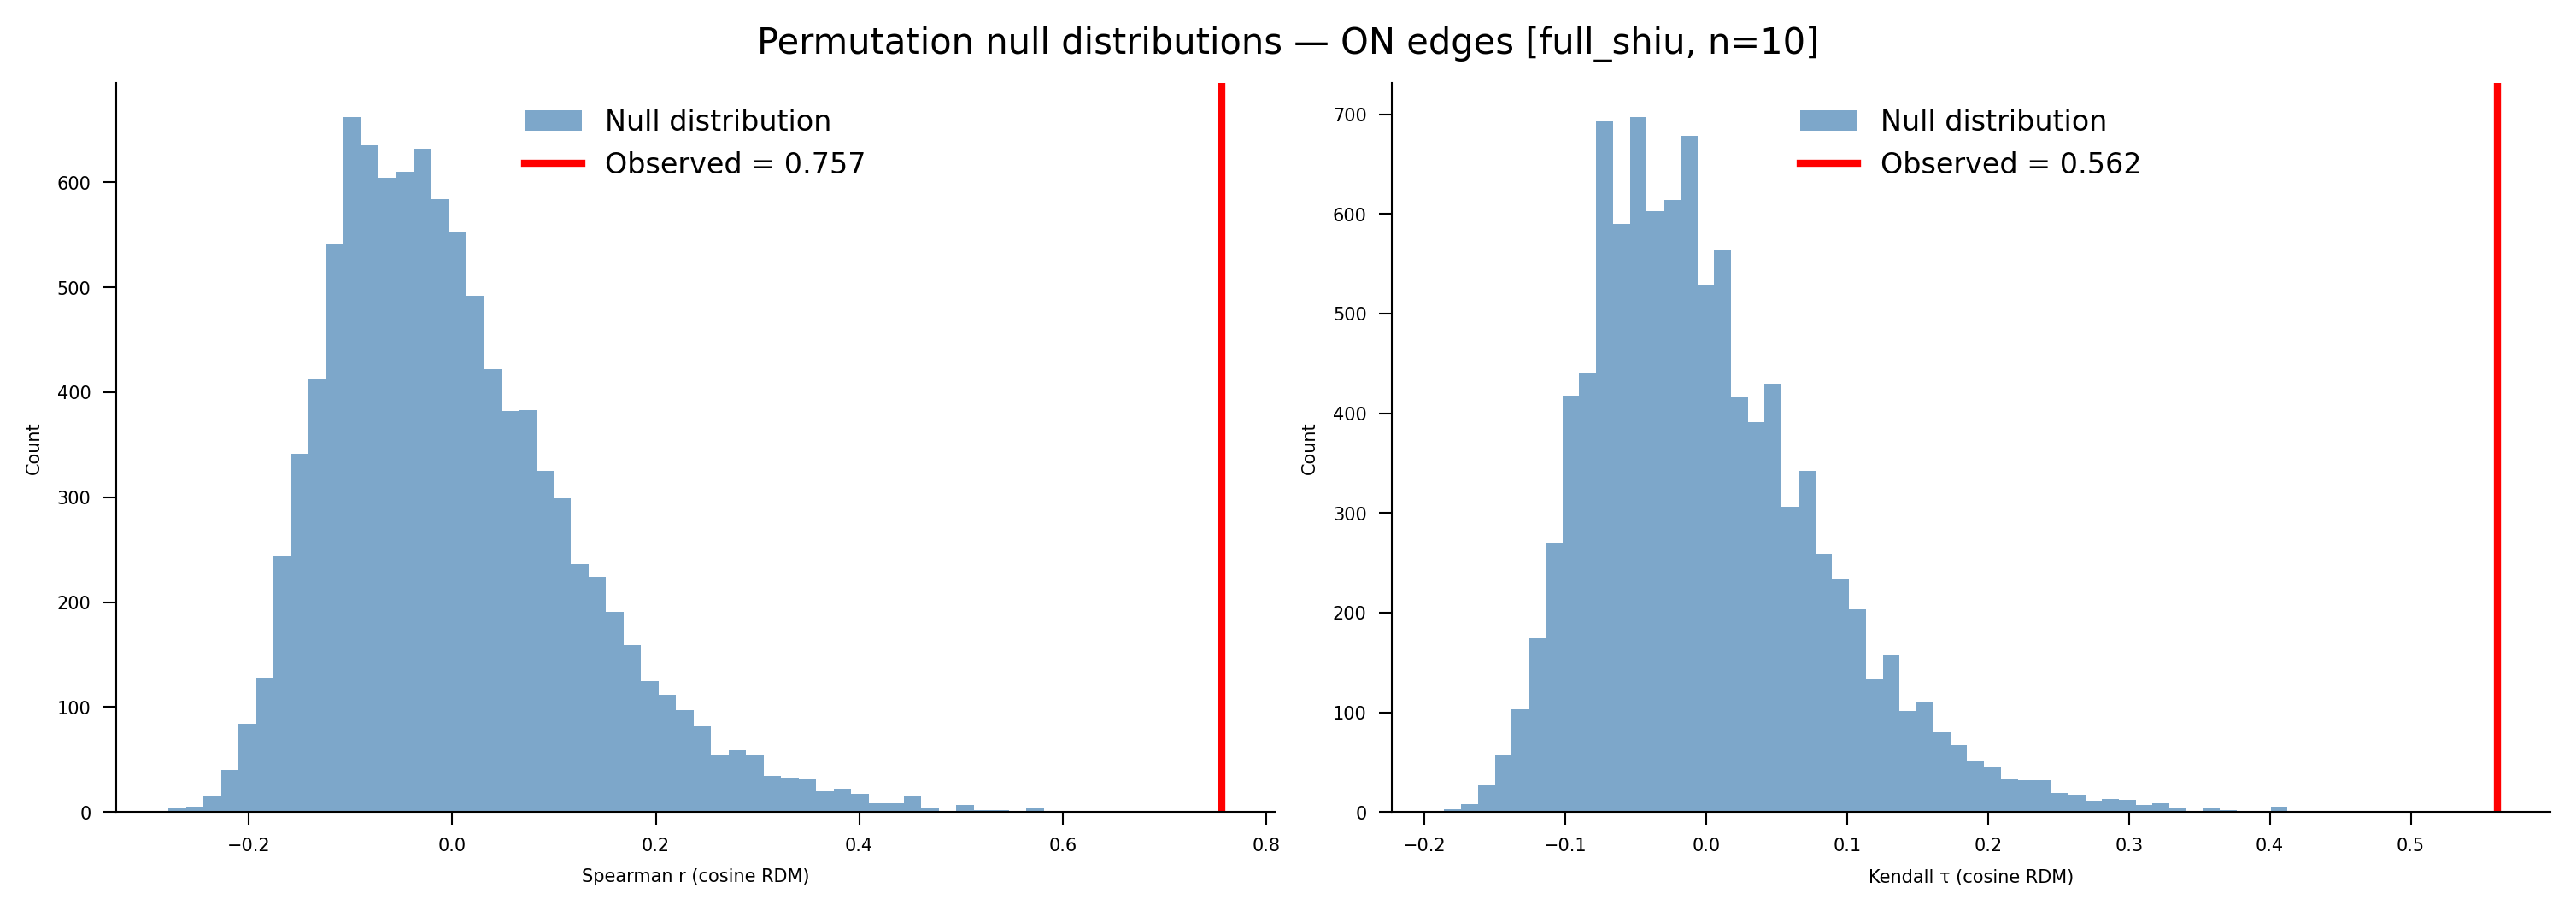


  Interpretation:
  Low r  → CC and random networks have DIFFERENT representational geometry
  High r → similar geometry (random network could substitute connectome)

--- WITHIN-ENSEMBLE RDM CONSISTENCY (CC models) ---
  Mean pairwise RDM correlation across CC models: 0.838 ± 0.078

--- GENERATING FIGURE ---
  Saved: moving_edge_on_rdms_10models_full_shiu.png


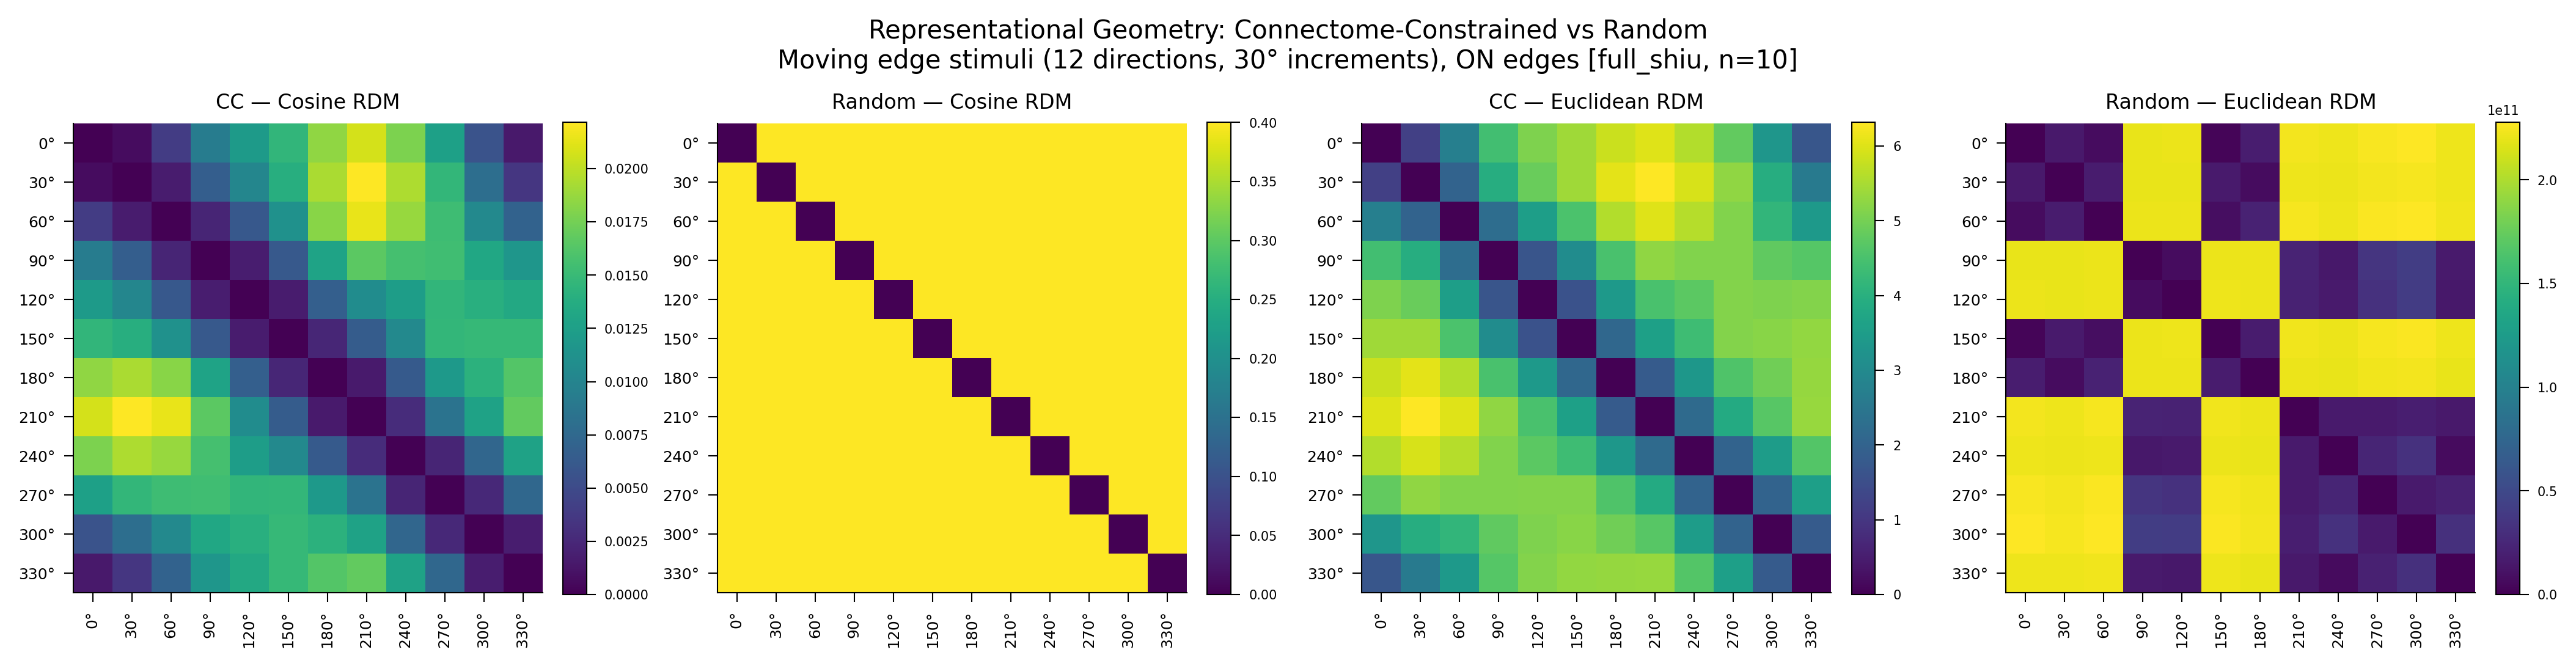


SUMMARY
  N stimuli:              12 (ON edges, 12 directions)
  N models:               10
  Randomization strategy: full_shiu
  Population vec dim:     65 (cell types)
  Cosine RDM corr (CC vs random):    Spearman r = 0.757 | Kendall τ = 0.562  [analytical]
                                     Spearman r = 0.757, p_perm = 0.0000 | Kendall τ = 0.562, p_perm = 0.0000  [permutation]
  Euclidean RDM corr (CC vs random): Spearman r = 0.094 | Kendall τ = 0.056  [analytical]
  Within-CC consistency:             r = 0.838 ± 0.078


{'cc_rdm_cosine': array([[0.        , 0.00076272, 0.00390109, 0.00933269, 0.01211477,
         0.01463336, 0.01853461, 0.02076964, 0.01777225, 0.01260695,
         0.00569689, 0.00149767],
        [0.00076272, 0.        , 0.00171486, 0.00665033, 0.0101805 ,
         0.01393343, 0.01938044, 0.02218335, 0.01949418, 0.01472135,
         0.00803022, 0.00349214],
        [0.00390109, 0.00171486, 0.        , 0.00227678, 0.00607807,
         0.01123016, 0.01824479, 0.02148717, 0.01873688, 0.01528383,
         0.01044791, 0.00697228],
        [0.00933269, 0.00665033, 0.00227678, 0.        , 0.00175131,
         0.00616892, 0.01289189, 0.01656505, 0.0156758 , 0.01533946,
         0.01325379, 0.01162291],
        [0.01211477, 0.0101805 , 0.00607807, 0.00175131, 0.        ,
         0.00165281, 0.00669971, 0.01078339, 0.01235404, 0.01461886,
         0.01402209, 0.0134293 ],
        [0.01463336, 0.01393343, 0.01123016, 0.00616892, 0.00165281,
         0.        , 0.0023755 , 0.006423  , 0.0104252

In [4]:
results = run_experiment(n_models=10, randomization_strategy="full_shiu")
results

## Save Results to File

In [5]:
# Save results to .npz file
np.savez("results_exp1.npz",
    cc_rdm_cosine=results["cc_rdm_cosine"],
    rand_rdm_cosine=results["rand_rdm_cosine"],
    cc_rdm_eucl=results["cc_rdm_eucl"],
    rand_rdm_eucl=results["rand_rdm_eucl"],
    cell_types=results["cell_types"],
)
print("Saved results_exp1.npz")

Saved results_exp1.npz


## Results

### CC Cosine RDM
The connectome-constrained network produces a structured 12×12 dissimilarity matrix with clear direction-dependent organization. Off-diagonal values range from ~0.001 to ~0.022 — small in absolute terms but systematically organized: adjacent directions are most similar (minimum: 0°–30°, dissimilarity = 0.001), while opposite directions are most dissimilar (maximum: 30°–210°, dissimilarity = 0.022). At n=50, the range tightens to 0.001–0.012, reflecting the inclusion of lower-performing models. Both runs show a smooth circular gradient consistent with the known direction tuning of T4/T5 neurons in the fly visual system.

### Random Cosine RDM
Under the full Shiu-style shuffle at n=10 (5/10 stable random models), the random baseline produces a nearly uniform matrix with all off-diagonal values at ~0.400 — the random network cannot distinguish motion directions, with directional variation confined to the fourth decimal place. Across all three randomization strategies tested at n=50 — (1) Shiu-style shuffling of all free parameters, (2) matched-normal resampling of all free parameters, and (3) Shiu-style shuffling of synaptic weights only (`edges_syn_strength`) while preserving trained time constants and resting potentials — the mean random cosine RDM collapses to NaN due to numerical overflow from unstable models. The same pattern holds at n=10 under the synapse-only shuffle (8/10 unstable). Instability is a fundamental property of random weight configurations in this architecture, not an artifact of any particular randomization strategy or ensemble size.

### Dynamic Instability
Dynamic instability is robust across all randomization strategies tested. Under the full Shiu-style shuffle at n=10, 5 of 10 random models (models 2, 3, 4, 8, 9) were unstable (756 non-finite values each, corresponding to 63 of 65 cell types across all 12 stimuli) — identical to the historical run, confirming that the instability pattern is fully reproducible under seed=42. Under the synapse-only shuffle at n=10, 8 of 10 (80%) were unstable. At n=50: full Shiu-style shuffling produced 33/50 unstable models (66%); matched-normal resampling produced 38/50 (76%); synapse-only shuffling produced 34/50 (68%). 0 of 50 trained CC models showed any instability under any condition. The biological connectome, as optimized by task training, reliably occupies a dynamically stable region of parameter space that random weight configurations consistently leave.

### CC vs Random RDM Correlation
Under the full Shiu-style shuffle at n=10 with 5/10 stable random models, cosine RDM correlation: **Spearman r = 0.757, p < 0.0001 | Kendall τ = 0.562, p < 0.0001** (analytical); **p_perm < 0.0001 for both measures** (stimulus-label randomization test, 10,000 permutations, Nili et al. 2014) — zero of 10,000 permutations exceeded the observed correlation. This result is highly significant by all inference methods, confirmed reproducible under torch.`use_deterministic_algorithms(True)` with `seed=42`. The CC and random cosine RDMs share directional ordering — both assign smaller dissimilarities to adjacent directions and larger dissimilarities to opposing ones — but differ substantially in depth and resolution: the CC network encodes direction with fine-grained dissimilarities spanning a 20-fold range (0.001–0.022), while the random baseline collapses that structure to a nearly uniform ~0.400 with no functionally meaningful variation.

Cosine RDM correlation is **NaN** under the canonical synapse-only shuffle at both n=10 (8/10 unstable) and n=50 (34/50 unstable) — not computable due to numerical overflow.

Euclidean RDM correlation: **Spearman r = 0.094, p = 0.451 | Kendall τ = 0.056, p = 0.503** (analytical); **p_perm = 0.190 | p_perm = 0.213** (permutation) — not significant by either inference method (full Shiu-style shuffle, n=10). Across all other conditions: **Spearman r = 0.021, p = 0.865** (full Shiu-style shuffle, n=50); **Spearman r = 0.241, p = 0.052** (matched-normal resampling, n=50); **Spearman r = 0.177, p = 0.156 | Kendall τ = 0.122, p = 0.149** (synapse-only shuffle, n=50); **Spearman r = 0.136, p = 0.278 | Kendall τ = 0.088, p = 0.296** (synapse-only shuffle, n=10) — none significant, and not interpretable due to extreme magnitudes from exploding activations in unstable random models.

**Interpretive note**: The cosine RDM correlation result is significant by analytical p-values, Kendall τ, and permutation test — three independent inference methods all converging on the same conclusion. The Euclidean result is non-significant by all methods including permutation, providing clean confirmation that it carries no fidelity signal under these conditions.

### Within-Ensemble Consistency
At n=10, mean pairwise RDM correlation: **r = 0.838 ± 0.078** (range: 0.601–0.956). At n=50, mean pairwise RDM correlation: **r = 0.721 ± 0.150** (range: 0.323–0.983). The decrease in mean and increase in variance at n=50 reflects the inclusion of lower-performing models implementing more varied solutions, consistent with the known cluster structure of the Flyvis ensemble reported in Lappalainen et al. Fig. 3.

## Discussion
- Dynamic instability persists across all tested randomization strategies and ensemble sizes (66–80%), indicating that the trained parameter configuration as a whole determines dynamic stability; a fully stable random baseline may require adversarial stability-constrained sampling
- Euclidean metric is not suitable when random baselines are dynamically unstable; cosine distance is the appropriate primary metric for this comparison — confirmed by permutation testing
- Within-CC consistency should be reported separately per cluster if UMAP reveals substructure in the ensemble geometry (planned)

## Download Figure

In [6]:
# Download figure to local machine
files.download("moving_edge_on_rdms_10models_full_shiu.png")
files.download("moving_edge_on_permtest_10models_full_shiu.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Download Results File

In [7]:
files.download("results_exp1.npz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>